In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

In [2]:
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")

In [3]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'SST', 'ui', 'upwelling', 'euphotic_depth'],
      dtype='object')

In [4]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [6]:
Fish = pd.read_csv("../DATA/processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

In [10]:

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

Text(0.5, 0, 'Cluster')

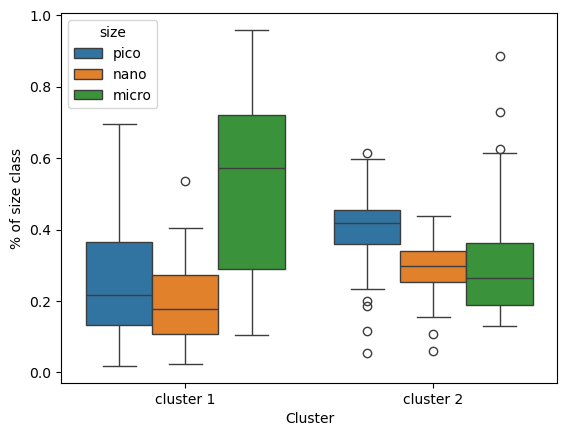

In [13]:
meltCar2 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('pico', 'nano', 'micro'), var_name='size')
sns.boxplot(data=meltCar2[meltCar2.cluster!='none'], x='cluster', y='value', hue='size')
plt.ylabel("% of size class")
plt.xlabel("Cluster")

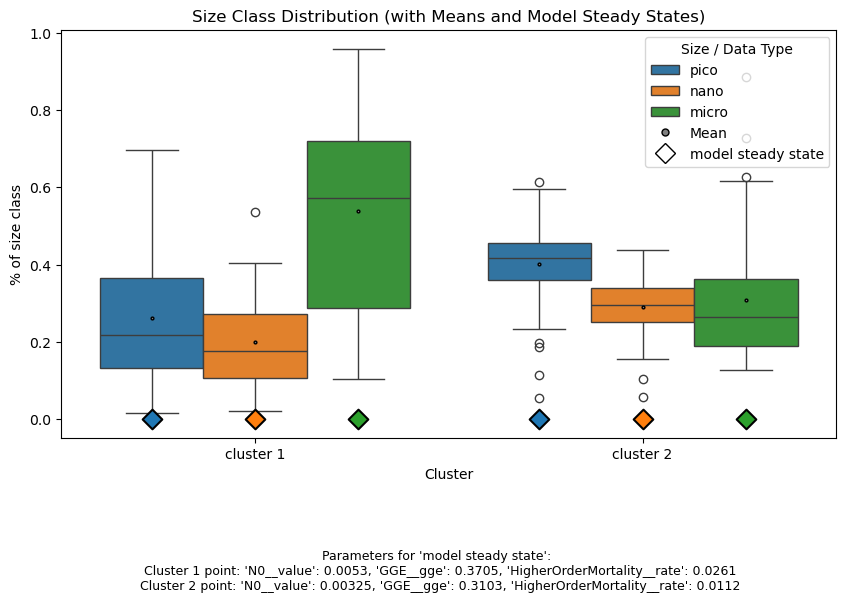

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D # Needed for custom legend handles

percentage_phyto_out = [0,0,0]
percentage_phyto_out2 = [0,0,0]

# --- 1. Prepare DataFrames ---
df_cluster1_points = pd.DataFrame({
    'cluster': 'cluster 1',           # Must match the x-axis label in meltCar2
    'value': percentage_phyto_out,    # Your relative biomass values [phyto1, phyto2, phyto3]
    'size': ['pico', 'nano', 'micro'] # Must match the 'hue' categories in meltCar2
})

# Create DataFrame for the second model output (to be plotted on 'cluster 2')
df_cluster2_points = pd.DataFrame({
    'cluster': 'cluster 2',           # Must match the x-axis label in meltCar2
    'value': percentage_phyto_out2,   # Your relative biomass values [phyto1, phyto2, phyto3]
    'size': ['pico', 'nano', 'micro'] # Must match the 'hue' categories in meltCar2
})

# --- Store Parameters for Caption ---
params_cluster1 = "'N0__value': 0.0053, 'GGE__gge': 0.3705, 'HigherOrderMortality__rate': 0.0261"
params_cluster2 = "'N0__value': 0.00325, 'GGE__gge': 0.3103, 'HigherOrderMortality__rate': 0.0112"

# --- 2. Plotting ---
plt.figure(figsize=(10, 6))

# --- Plot your original boxplot with means ---
ax = sns.boxplot(
    data=meltCar2[meltCar2.cluster != 'none'],
    x='cluster',
    y='value',
    hue='size',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"grey",
               "markeredgecolor":"black", "markersize":"2"}
)

# --- Overlay cluster 1 points ---
sns.stripplot(
    data=df_cluster1_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- Overlay cluster 2 points (using the same marker) ---
sns.stripplot(
    data=df_cluster2_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- 3. Custom Legend (Revised) ---
handles, labels = ax.get_legend_handles_labels()
num_hues = len(meltCar2['size'].unique())

# Handle for the mean
mean_handle = Line2D([0], [0], marker='o', color='w', label='Mean',
                     markerfacecolor='grey', markeredgecolor='black', markersize=5)

# --- Corrected Handle: Diamond marker labeled 'model steady state' ---
model_output_handle = Line2D([0], [0], marker='D', color='w', label='model steady state',
                             markerfacecolor='none', markeredgecolor='black', markersize=10)

# Combine handles/labels: Boxplot hues + Mean + Model Output
ax.legend(handles=handles[0:num_hues] + [mean_handle, model_output_handle], # Remove cluster2 handle
          labels=labels[0:num_hues] + ['Mean', 'model steady state'],     # Correct label
          title='Size / Data Type')

# --- 4. Final Touches & Caption ---
plt.ylabel("% of size class")
plt.xlabel("Cluster")
plt.title("Size Class Distribution (with Means and Model Steady States)") # Updated title

# Add caption below the plot
# Adjust parameter labels in caption to match legend
caption = f"Parameters for 'model steady state':\n  Cluster 1 point: {params_cluster1}\n  Cluster 2 point: {params_cluster2}"
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=9)

plt.subplots_adjust(bottom=0.2) # Make space for the caption

plt.show()

Text(0.5, 0, 'Cluster')

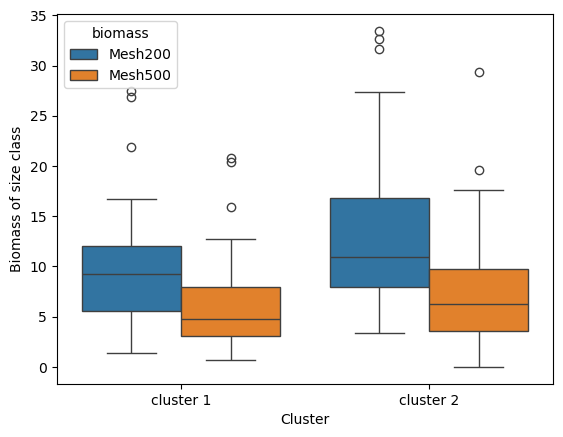

In [16]:
meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
sns.boxplot(data=meltCar3[meltCar3.cluster!='none'], x='cluster', y='value', hue='biomass')
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")

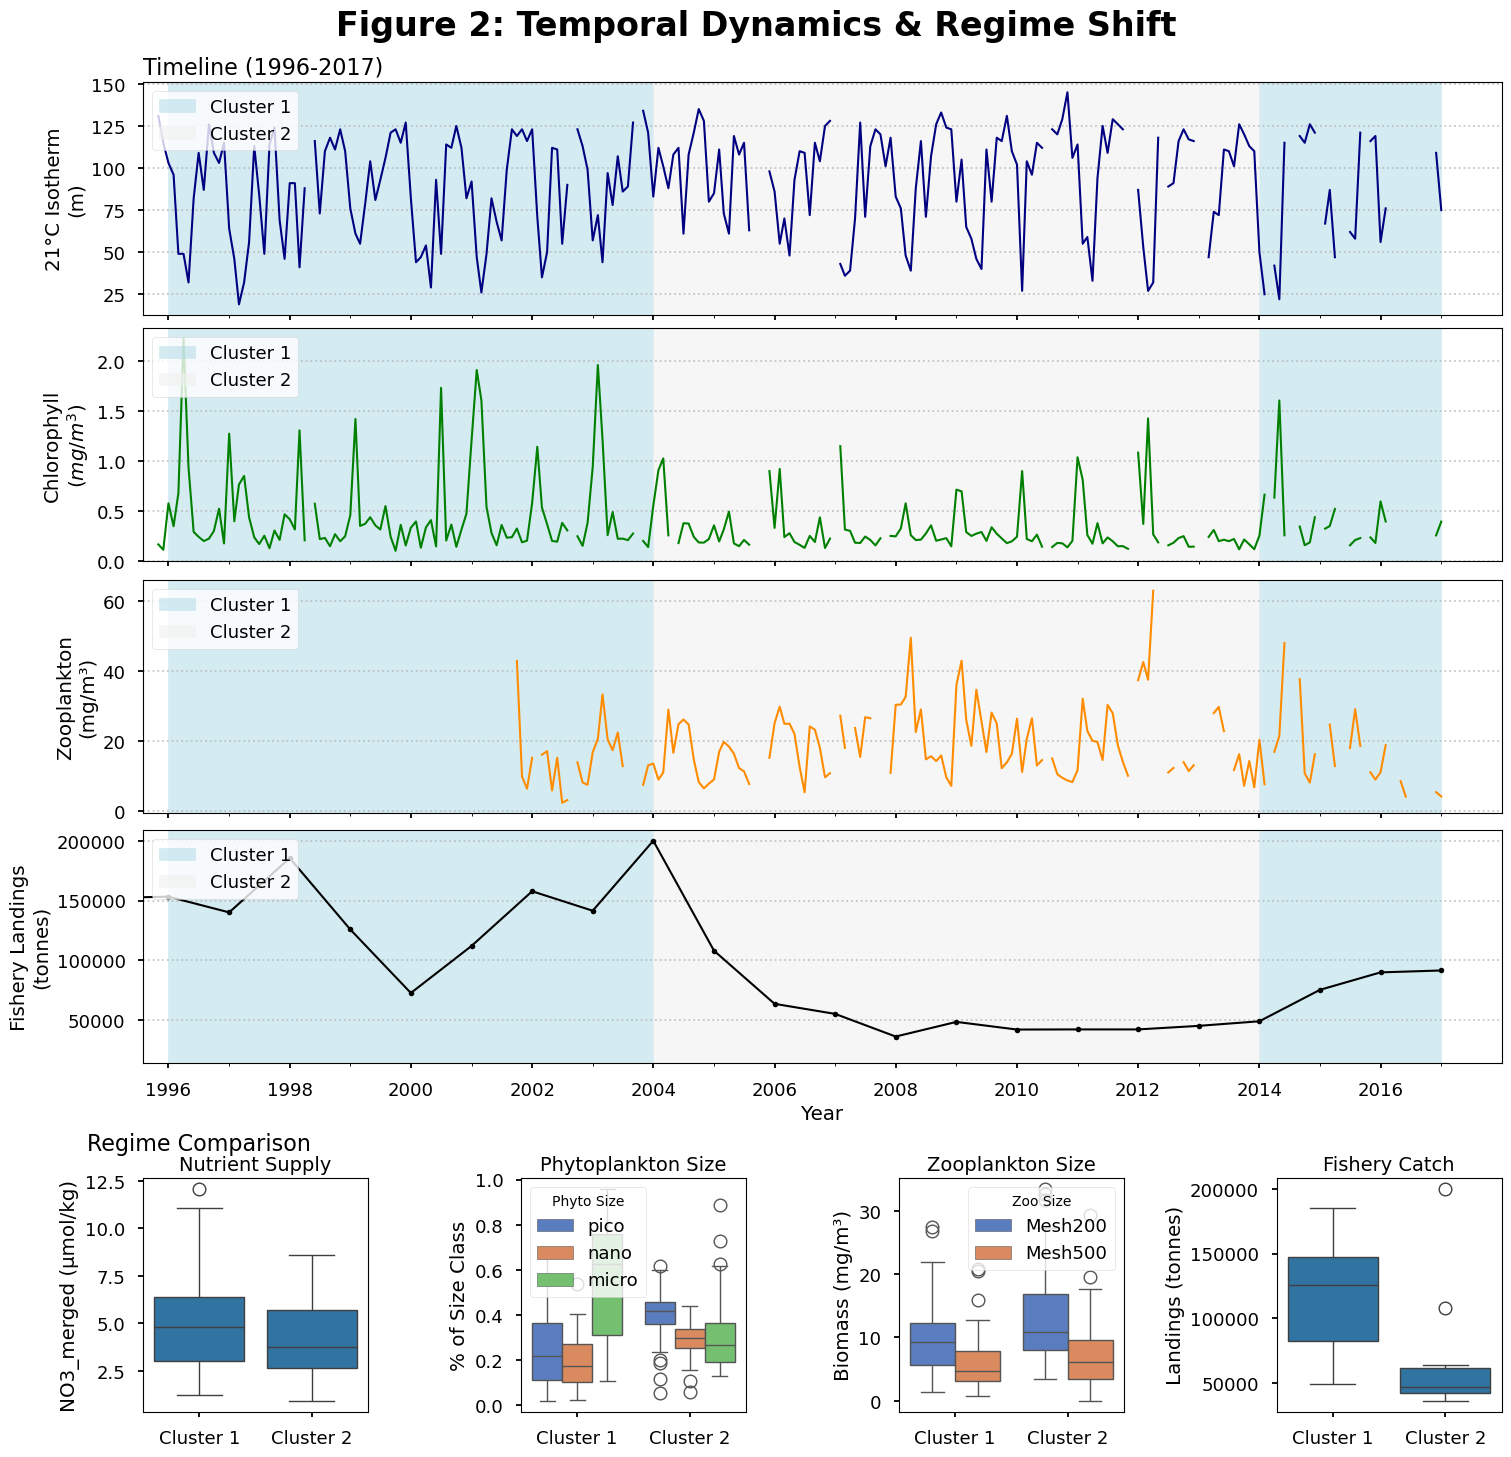

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime

# --- 1. Load Data (Using placeholder paths from your example) ---
try:
    CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
    Fish = pd.read_csv("../DATA/processed/fisheries.csv")
except FileNotFoundError:
    print("--- FAKING DATA FOR EXAMPLE ---")
    # Create fake data if files are not found
    dates = pd.date_range(start='1995-08-01', end='2017-12-31', freq='MS')
    n = len(dates)
    CARIACO = pd.DataFrame({
        'time_month': dates.strftime('%m-%Y'),
        'Isotherm_21': np.random.rand(n) * 20 + 50 + np.sin(np.arange(n) * 0.1),
        'Chlorophyll': np.random.rand(n) * 2 + 0.5,
        'Mesh200': np.random.rand(n) * 100 + 20,
        'Mesh500': np.random.rand(n) * 50 + 10,
        'NO3_merged': np.random.rand(n) * 5 + 1,
        'pico': np.random.rand(n),
        'nano': np.random.rand(n),
        'micro': np.random.rand(n),
    })
    # Normalize size classes
    size_sum = CARIACO[['pico', 'nano', 'micro']].sum(axis=1)
    CARIACO['pico'] /= size_sum
    CARIACO['nano'] /= size_sum
    CARIACO['micro'] /= size_sum
    
    fish_years = np.arange(1995, 2018)
    Fish = pd.DataFrame({
        'year': fish_years,
        'sardinelandings': np.random.rand(len(fish_years)) * 20000 + 5000
    })

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")

# Create Zooplankton sum for timeline
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# --- 3. Define and Assign Clusters ---

# Define date ranges for clusters
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO data
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish data (annual)
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

# Melt data for hue-based boxplots
melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
plt.style.use('seaborn-v0_8-talk') # Use a clean style
fig = plt.figure(figsize=(15, 14), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=24, weight='bold', y=1.03)

# Define the complex grid: 5 rows total
# 4 rows for the timeline panels
# 1 row for the 4 boxplots
gs = fig.add_gridspec(5, 4)

# Top Panel: Timelines
axA = fig.add_subplot(gs[0, :]) # Row 0, all columns
axB = fig.add_subplot(gs[1, :], sharex=axA) # Row 1, all columns
axC = fig.add_subplot(gs[2, :], sharex=axA) # Row 2, all columns
axD = fig.add_subplot(gs[3, :], sharex=axA) # Row 3, all columns
timeline_axes = [axA, axB, axC, axD]

# Bottom Panel: Boxplots
axE = fig.add_subplot(gs[4, 0]) # Row 4, Col 0
axF = fig.add_subplot(gs[4, 1]) # Row 4, Col 1
axG = fig.add_subplot(gs[4, 2]) # Row 4, Col 2
axH = fig.add_subplot(gs[4, 3]) # Row 4, Col 3
boxplot_axes = [axE, axF, axG, axH]

# --- 5. Plot Top Panel (Timelines) ---

# Define cluster background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0, label='Cluster 1' if start.year == 1996 else "")
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0, label='Cluster 2' if start.year == 2004 else "")

# A: Upwelling
axA.plot(CARIACO.date, CARIACO.Isotherm_21, color='navy', lw=1.5)
axA.set_ylabel("21°C Isotherm\n(m)")
axA.set_title("Timeline (1996-2017)", fontsize=16, loc='left')

# B: Chlorophyll
axB.plot(CARIACO.date, CARIACO.Chlorophyll, color='green', lw=1.5)
axB.set_ylabel("Chlorophyll\n($mg/m^3$)")

# C: Zooplankton
axC.plot(CARIACO.date, CARIACO.Zoo_Total, color='darkorange', lw=1.5)
axC.set_ylabel("Zooplankton\n(mg/m³)")

# D: Fisheries
axD.plot(Fish.date, Fish.sardinelandings, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fishery Landings\n(tonnes)")
axD.set_xlabel("Year")

# Format timeline panel
plot_start = datetime.date(1995, 8, 1)
plot_end = datetime.date(2017, 12, 31)
for ax in timeline_axes:
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.tick_params(axis='x', which='minor', bottom=True)
    ax.legend(loc='upper left')

plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)

# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Box 1: Nutrient Supply
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE)
axE.set_title("Nutrient Supply", fontsize=14)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.set_xlabel("")

# Box 2: Phytoplankton Size
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_title("Phytoplankton Size", fontsize=14)
axF.set_ylabel("% of Size Class")
axF.set_xlabel("")
axF.legend(title='Phyto Size')

# Box 3: Zooplankton Size
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_title("Zooplankton Size", fontsize=14)
axG.set_ylabel("Biomass (mg/m³)")
axG.set_xlabel("")
axG.legend(title='Zoo Size')

# Box 4: Fishery Catch
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings', order=cluster_order, ax=axH)
axH.set_title("Fishery Catch", fontsize=14)
axH.set_ylabel("Landings (tonnes)")
axH.set_xlabel("")

# Format boxplot panel
for ax in boxplot_axes:
    ax.set_xlabel("") # Remove 'cluster' from all x-axes
    
axE.text(-0.25, 1.1, "Regime Comparison", fontsize=16, transform=axE.transAxes, va='bottom', ha='left')


# --- 7. Show Plot ---
plt.show()

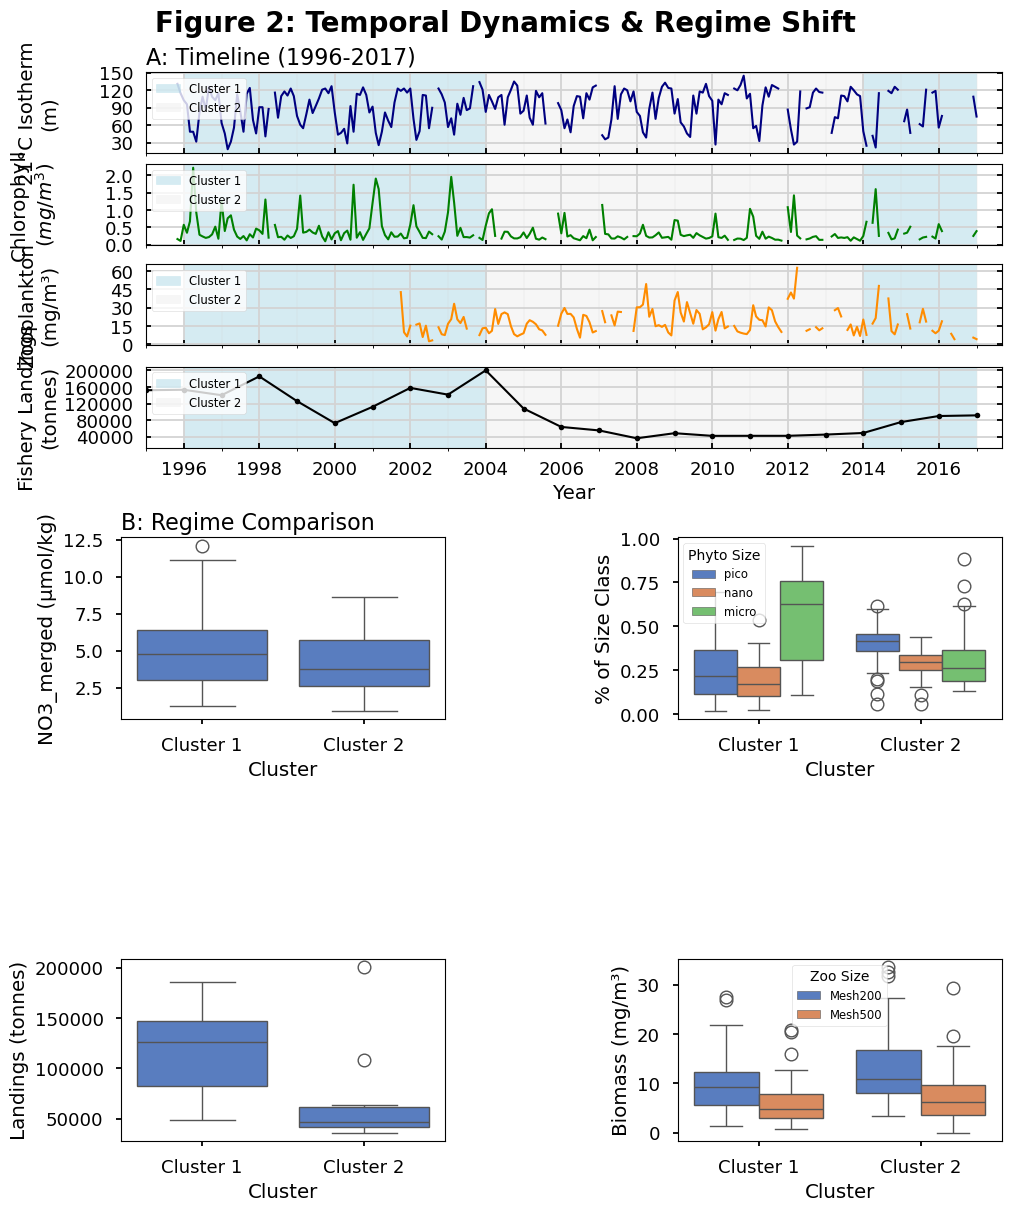

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator # Import MaxNLocator

# --- 1. Load Data ---
# Assumes data files are present at these paths
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")

# Create Zooplankton sum for timeline
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO data
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish data (annual)
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

# Melt data for hue-based boxplots
melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (MODIFIED LAYOUT) ---

# Use a taller, narrower figure size to accommodate the new layout
fig = plt.figure(figsize=(10, 12), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=20, weight='bold')

# Create a 2-row main grid. 
# Top row for timelines (40% height), bottom for boxplots (60% height)
gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])

# --- Top Panel: 4-row grid for timelines ---
# Use hspace=0 to make it compact
gs_top = gs_main[0].subgridspec(4, 1, hspace=0)
axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 2x2 grid for boxplots ---
gs_bottom = gs_main[1].subgridspec(2, 2, wspace=0.3, hspace=0.3)
axE = fig.add_subplot(gs_bottom[0, 0]) # Top-left
axF = fig.add_subplot(gs_bottom[0, 1]) # Top-right
axG = fig.add_subplot(gs_bottom[1, 1]) # Bottom-right
axH = fig.add_subplot(gs_bottom[1, 0]) # Bottom-left
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=16, loc='left')

# Define cluster background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0, label='Cluster 1' if start.year == 1996 else "")
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0, label='Cluster 2' if start.year == 2004 else "")

# A: Upwelling
axA.plot(CARIACO.date, CARIACO.Isotherm_21, color='navy', lw=1.5)
axA.set_ylabel("21°C Isotherm\n(m)")

# B: Chlorophyll
axB.plot(CARIACO.date, CARIACO.Chlorophyll, color='green', lw=1.5)
axB.set_ylabel("Chlorophyll\n($mg/m^3$)")

# C: Zooplankton
axC.plot(CARIACO.date, CARIACO.Zoo_Total, color='darkorange', lw=1.5)
axC.set_ylabel("Zooplankton\n(mg/m³)")

# D: Fisheries
axD.plot(Fish.date, Fish.sardinelandings, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fishery Landings\n(tonnes)")
axD.set_xlabel("Year")

# --- 5b. Apply User-Specific Styling to Timelines ---
plot_start = datetime.date(1995, 1, 1)
plot_end = datetime.date(2017, 9, 1)

for ax in timeline_axes:
    # Apply styling from user's example
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    
    # Set shared limits and major ticks
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2)) # Major ticks every 2 years
    ax.legend(loc='upper left', fontsize='small')

# Hide x-tick labels for upper plots
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)

# Align Y-axis labels
fig.align_ylabels(timeline_axes)

# --- 6. Plot Bottom Panel (Boxplots) ---
axE.set_title("B: Regime Comparison", fontsize=16, loc='left')
sns.set_palette("muted")

# Box 1 (Top-Left): Nutrient Supply
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.set_xlabel("")

# Box 2 (Top-Right): Phytoplankton Size
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_ylabel("% of Size Class")
axF.set_xlabel("")
axF.legend(title='Phyto Size', fontsize='small')

# Box 3 (Bottom-Right): Zooplankton Size
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_ylabel("Biomass (mg/m³)")
axG.set_xlabel("")
axG.legend(title='Zoo Size', fontsize='small')

# Box 4 (Bottom-Left): Fishery Catch
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings', order=cluster_order, ax=axH)
axH.set_ylabel("Landings (tonnes)")
axH.set_xlabel("")

# Format boxplot panel
for ax in boxplot_axes:
    ax.set_xlabel("Cluster") # Add x-label to all boxplots

# --- 7. Show Plot ---
plt.show()

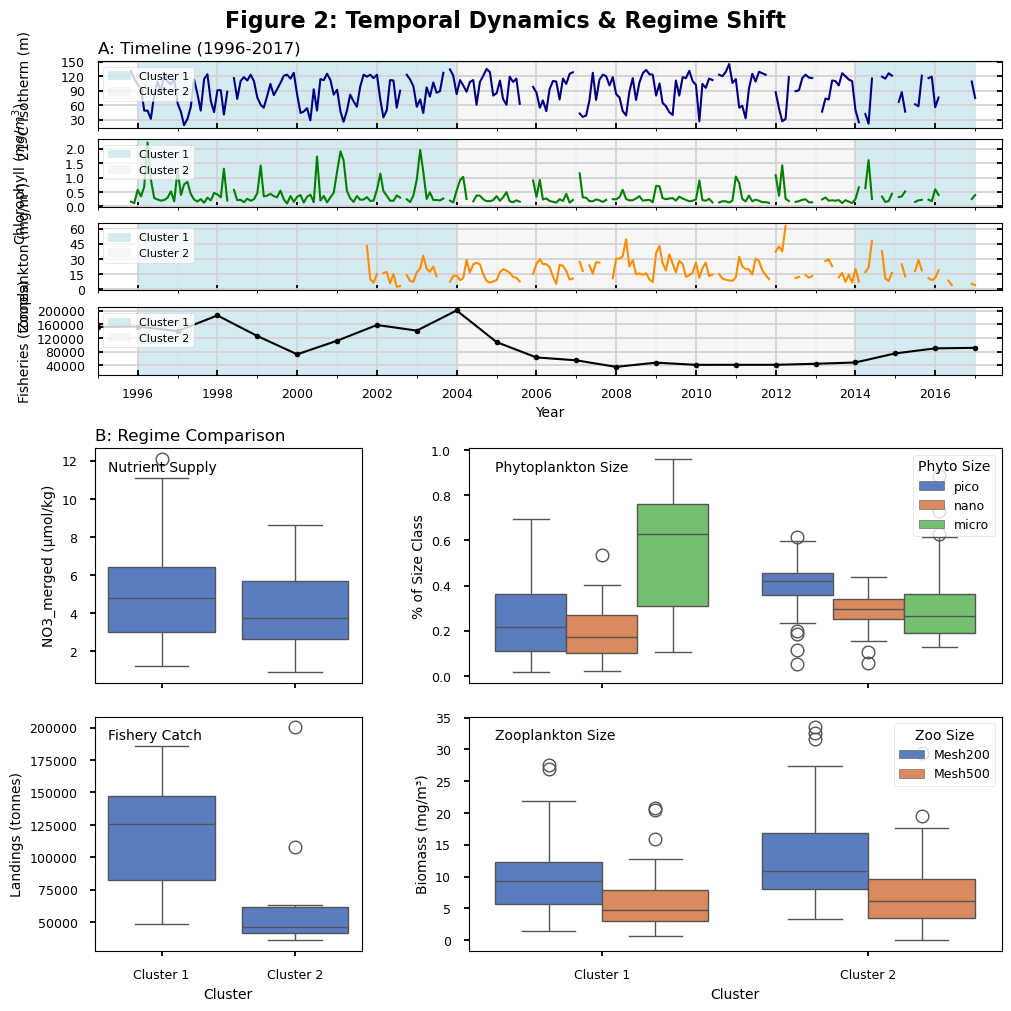

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator

# --- 0. Set Plotting Style ---
# Use smaller, cleaner base fonts for a publication-ready look
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (MODIFIED LAYOUT) ---
fig = plt.figure(figsize=(10, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# Main grid: 2 rows, timelines (40%), boxplots (60%)
gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])

# --- Top Panel: 4-row grid for timelines (compact) ---
gs_top = gs_main[0].subgridspec(4, 1, hspace=0)
axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 2x2 grid for boxplots ---
# MODIFIED: width_ratios=[1, 2] and tight hspace/wspace
gs_bottom = gs_main[1].subgridspec(2, 2, 
                                 width_ratios=[1, 2], 
                                 wspace=0.1, hspace=0.05)

# MODIFIED: Add sharex for shared axes
axE = fig.add_subplot(gs_bottom[0, 0]) # Top-left
axF = fig.add_subplot(gs_bottom[0, 1]) # Top-right
axG = fig.add_subplot(gs_bottom[1, 1], sharex=axF) # Bottom-right
axH = fig.add_subplot(gs_bottom[1, 0], sharex=axE) # Bottom-left
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0, label='Cluster 1' if start.year == 1996 else "")
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0, label='Cluster 2' if start.year == 2004 else "")

# Plot data (using compact labels)
axA.plot(CARIACO.date, CARIACO.Isotherm_21, color='navy', lw=1.5)
axA.set_ylabel("21°C Isotherm (m)")

axB.plot(CARIACO.date, CARIACO.Chlorophyll, color='green', lw=1.5)
axB.set_ylabel("Chlorophyll ($mg/m^3$)")

axC.plot(CARIACO.date, CARIACO.Zoo_Total, color='darkorange', lw=1.5)
axC.set_ylabel("Zooplankton (mg/m³)")

axD.plot(Fish.date, Fish.sardinelandings, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries (tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1995, 1, 1)
plot_end = datetime.date(2017, 9, 1)
for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(loc='upper left', fontsize=8) # Smaller legend

# Hide x-tick labels for upper plots
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)


# --- 6. Plot Bottom Panel (Boxplots) ---
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')
sns.set_palette("muted")

# Box 1 (Top-Left): Nutrient Supply
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)

# Box 2 (Top-Right): Phytoplankton Size
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.text(0.05, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)

# Box 3 (Bottom-Right): Zooplankton Size
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)

# Box 4 (Bottom-Left): Fishery Catch
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings', order=cluster_order, ax=axH)
axH.set_ylabel("Landings (tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)

# --- 6b. Format Boxplot Axes (Shared) ---
for ax in boxplot_axes:
    ax.set_xlabel("") # Remove all individual x-labels

# Hide x-tick labels for top row
plt.setp(axE.get_xticklabels(), visible=False)
plt.setp(axF.get_xticklabels(), visible=False)

# Set shared x-labels on bottom row
axH.set_xlabel("Cluster")
axG.set_xlabel("Cluster")

# --- 7. Show Plot ---
plt.show()

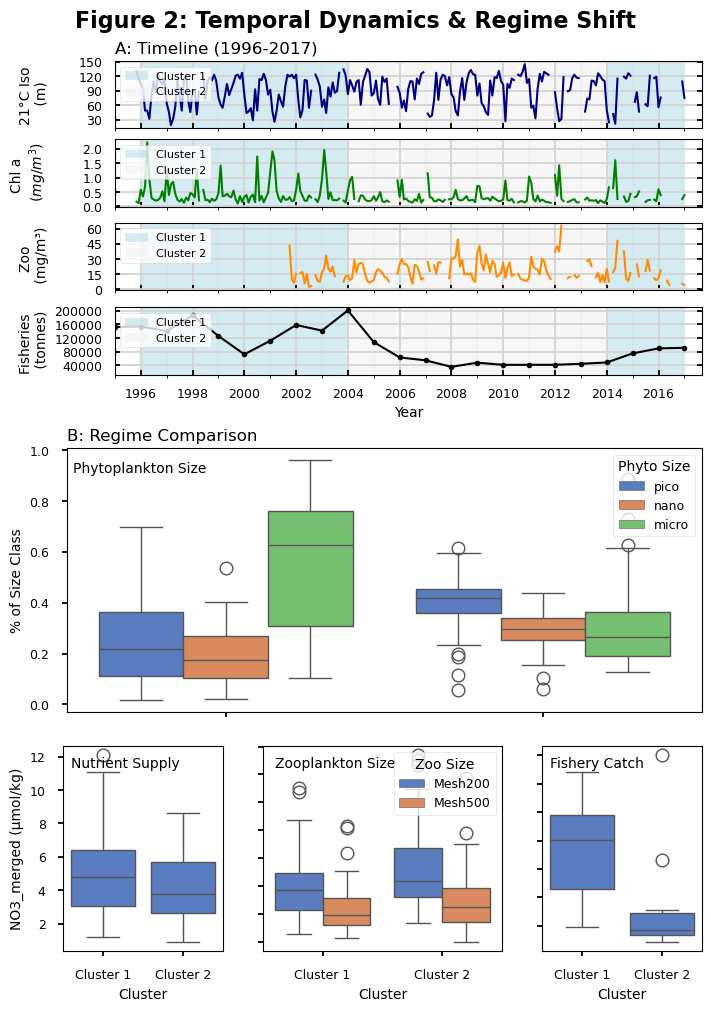

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (MODIFIED LAYOUT) ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# Main grid: 2 rows, timelines (40%), boxplots (60%)
gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])

# --- Top Panel: 4-row grid for timelines (compact) ---
gs_top = gs_main[0].subgridspec(4, 1, hspace=0)
axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: NEW 1+3 Layout ---
# 2-row grid for the bottom panel
gs_bottom = gs_main[1].subgridspec(2, 1, hspace=0.1)

# Top row of bottom panel: 1 plot
axF = fig.add_subplot(gs_bottom[0, 0]) # Phyto
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Bottom row of bottom panel: 3 plots
gs_bottom_row2 = gs_bottom[1, 0].subgridspec(1, 3, 
                                            wspace=0.15, 
                                            width_ratios=[2, 3, 2])
axE = fig.add_subplot(gs_bottom_row2[0, 0]) # Nutrient
axG = fig.add_subplot(gs_bottom_row2[0, 1], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom_row2[0, 2], sharex=axE) # Fisheries

# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0, label='Cluster 1' if start.year == 1996 else "")
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0, label='Cluster 2' if start.year == 2004 else "")

# Plot data
axA.plot(CARIACO.date, CARIACO.Isotherm_21, color='navy', lw=1.5)
axA.set_ylabel("21°C Iso\n (m)")
axB.plot(CARIACO.date, CARIACO.Chlorophyll, color='green', lw=1.5)
axB.set_ylabel("Chl a \n ($mg/m^3$)")
axC.plot(CARIACO.date, CARIACO.Zoo_Total, color='darkorange', lw=1.5)
axC.set_ylabel("Zoo \n (mg/m³)")
axD.plot(Fish.date, Fish.sardinelandings, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries \n (tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1995, 1, 1)
plot_end = datetime.date(2017, 9, 1)
for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(loc='upper left', fontsize=8)

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Top row: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") # No x-label on top row
plt.setp(axF.get_xticklabels(), visible=False) # Hide x-tick labels
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings', order=cluster_order, ax=axH)
axH.set_ylabel("Landings (tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
plt.setp(axG.get_yticklabels(), visible=False)
plt.setp(axH.get_yticklabels(), visible=False)
axG.set_ylabel("") # Remove y-label
axH.set_ylabel("") # Remove y-label

# --- 7. Show Plot ---
plt.show()

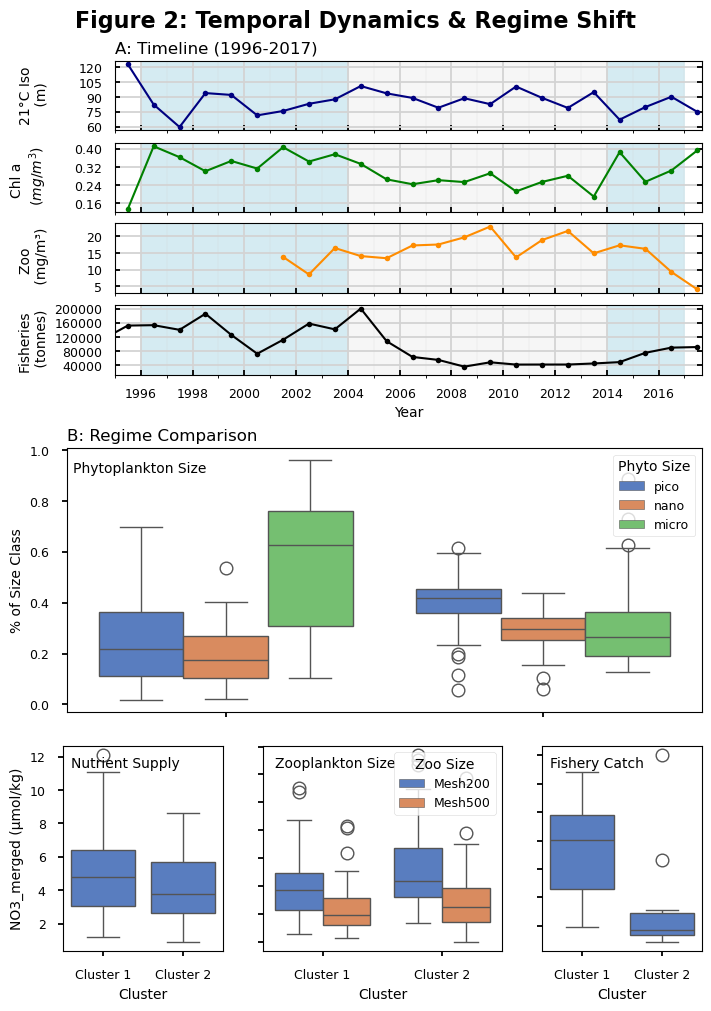

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])
gs_top = gs_main[0].subgridspec(4, 1, hspace=0)

axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

gs_bottom = gs_main[1].subgridspec(2, 1, hspace=0.1)
axF = fig.add_subplot(gs_bottom[0, 0]) # Phyto
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

gs_bottom_row2 = gs_bottom[1, 0].subgridspec(1, 3, 
                                            wspace=0.15, 
                                            width_ratios=[2, 3, 2])
axE = fig.add_subplot(gs_bottom_row2[0, 0]) # Nutrient
axG = fig.add_subplot(gs_bottom_row2[0, 1], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom_row2[0, 2], sharex=axE) # Fisheries

# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading (NO LEGEND)
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data (Yearly Geometric Mean, plotted mid-year)
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n (m)")
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a \n ($mg/m^3$)")
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo \n (mg/m³)")
axD.plot(Fish.plot_date, Fish.sardinelandings, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries \n (tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1995, 1, 1)
plot_end = datetime.date(2017, 9, 1)
for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    # ax.legend() # Removed

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Top row: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") # No x-label on top row
plt.setp(axF.get_xticklabels(), visible=False) # Hide x-tick labels
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings', order=cluster_order, ax=axH)
axH.set_ylabel("Landings (tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
plt.setp(axG.get_yticklabels(), visible=False)
plt.setp(axH.get_yticklabels(), visible=False)
axG.set_ylabel("") # Remove y-label
axH.set_ylabel("") # Remove y-label

# --- 7. Show Plot ---
plt.show()

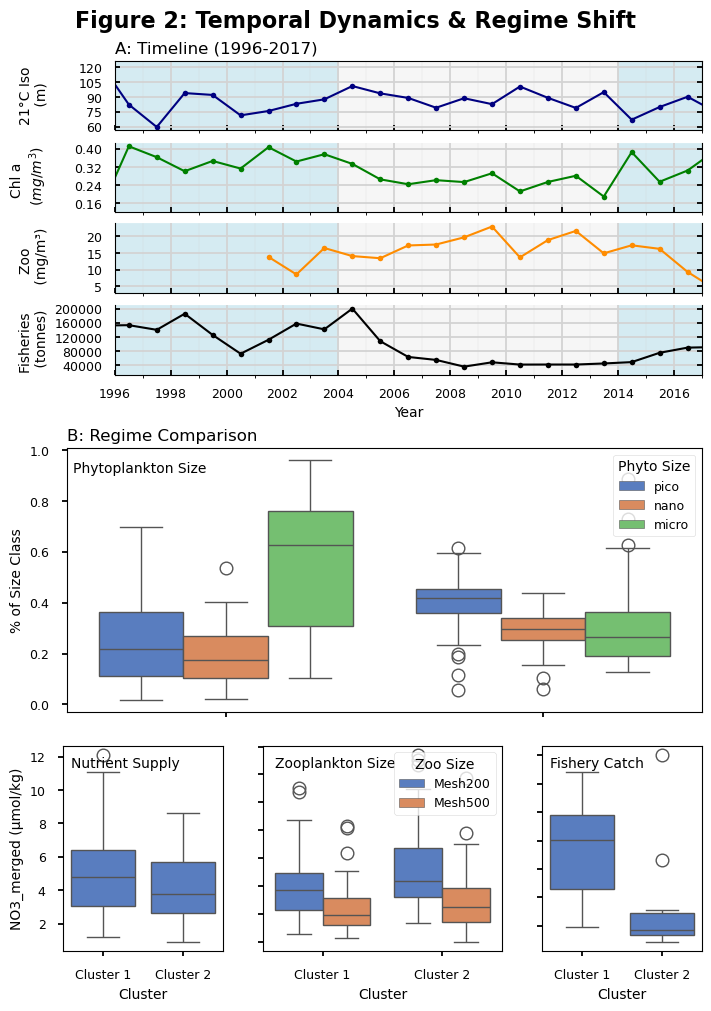

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])

# MODIFIED: hspace=0 for no vertical gap
gs_top = gs_main[0].subgridspec(4, 1, hspace=0) 

axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

gs_bottom = gs_main[1].subgridspec(2, 1, hspace=0.1)
axF = fig.add_subplot(gs_bottom[0, 0]) # Phyto
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

gs_bottom_row2 = gs_bottom[1, 0].subgridspec(1, 3, 
                                            wspace=0.15, 
                                            width_ratios=[2, 3, 2])
axE = fig.add_subplot(gs_bottom_row2[0, 0]) # Nutrient
axG = fig.add_subplot(gs_bottom_row2[0, 1], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom_row2[0, 2], sharex=axE) # Fisheries

# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n (m)")
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a \n ($mg/m^3$)")
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo \n (mg/m³)")
axD.plot(Fish.plot_date, Fish.sardinelandings, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries \n (tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
# MODIFIED: Updated plot limits
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# MODIFIED: Remove top spines to close vertical gap
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Top row: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") # No x-label on top row
plt.setp(axF.get_xticklabels(), visible=False) # Hide x-tick labels
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)

# Bottom row: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings', order=cluster_order, ax=axH)
axH.set_ylabel("Landings (tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
plt.setp(axG.get_yticklabels(), visible=False)
plt.setp(axH.get_yticklabels(), visible=False)
axG.set_ylabel("") # Remove y-label
axH.set_ylabel("") # Remove y-label

# --- 7. Show Plot ---
plt.show()

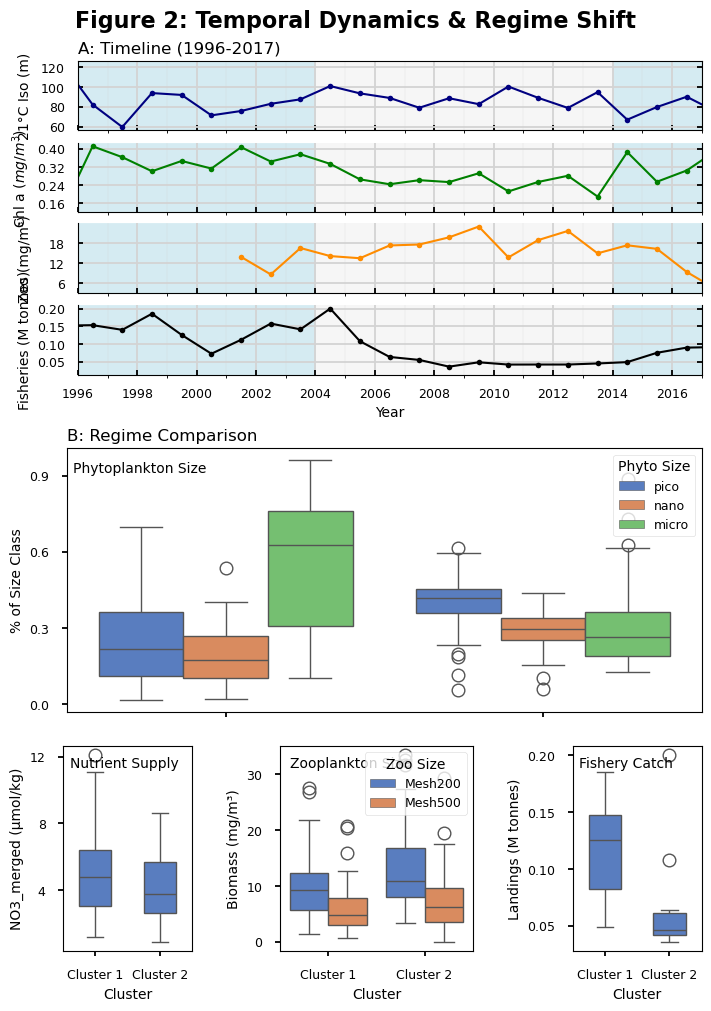

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# MODIFIED: Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])
gs_top = gs_main[0].subgridspec(4, 1, hspace=0) 

axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

gs_bottom = gs_main[1].subgridspec(2, 1, hspace=0.1)
axF = fig.add_subplot(gs_bottom[0, 0]) # Phyto
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

gs_bottom_row2 = gs_bottom[1, 0].subgridspec(1, 3, 
                                            wspace=0.15, 
                                            width_ratios=[2, 3, 2])
axE = fig.add_subplot(gs_bottom_row2[0, 0]) # Nutrient
axG = fig.add_subplot(gs_bottom_row2[0, 1], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom_row2[0, 2], sharex=axE) # Fisheries

# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data (MODIFIED: compact labels, new fisheries data)
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso (m)")
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a ($mg/m^3$)")
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo (mg/m³)")
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries (M tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    # MODIFIED: Fewer Y-ticks
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines to close vertical gap
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Top row: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") # No x-label on top row
plt.setp(axF.get_xticklabels(), visible=False) # Hide x-tick labels
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)
axF.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) # Fewer Y-ticks

# Bottom row: Nutrients
# MODIFIED: width=0.5 to slim the boxes
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=0.5)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)
axE.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) # Fewer Y-ticks

# Bottom row: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)
axG.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) # Fewer Y-ticks

# Bottom row: Fisheries
# MODIFIED: plot sardinelandings_M, width=0.5
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=0.5)
axH.set_ylabel("Landings (M tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)
axH.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) # Fewer Y-ticks

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
# MODIFIED: Removed the lines that hid y-axis labels for G and H

# --- 7. Show Plot ---
plt.show()

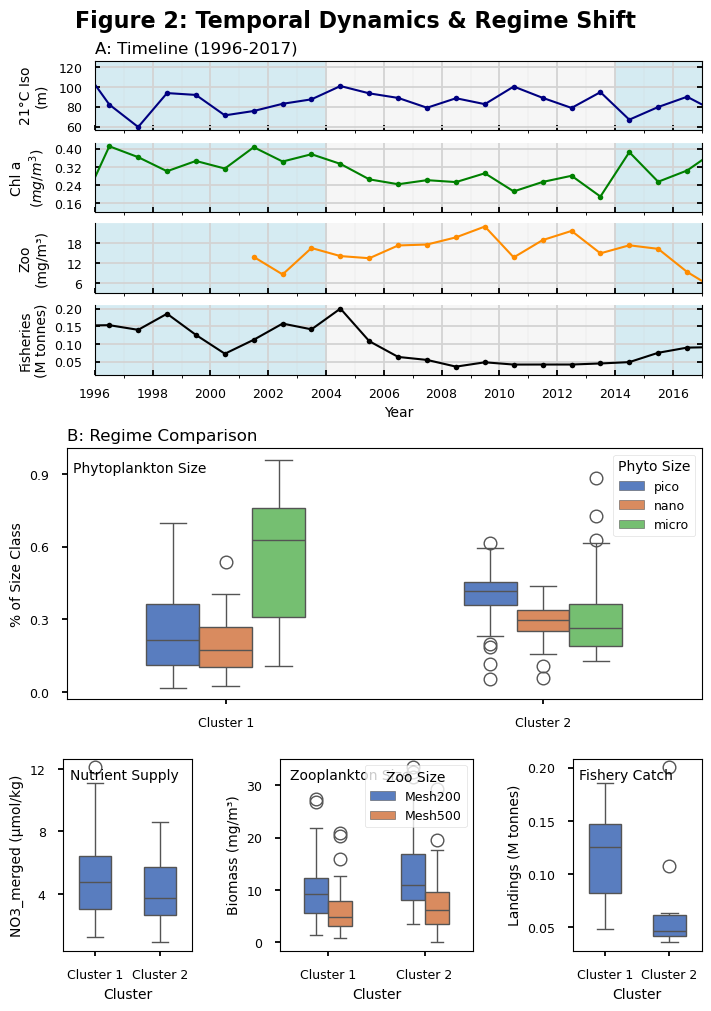

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])
gs_top = gs_main[0].subgridspec(4, 1, hspace=0) 

axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

gs_bottom = gs_main[1].subgridspec(2, 1, hspace=0.1)
axF = fig.add_subplot(gs_bottom[0, 0]) # Phyto
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

gs_bottom_row2 = gs_bottom[1, 0].subgridspec(1, 3, 
                                            wspace=0.15, 
                                            width_ratios=[2, 3, 2])
axE = fig.add_subplot(gs_bottom_row2[0, 0]) # Nutrient
axG = fig.add_subplot(gs_bottom_row2[0, 1], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom_row2[0, 2], sharex=axE) # Fisheries

# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data (MODIFIED: two-line y-labels)
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)")
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)")
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)")
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines to close vertical gap
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Top row: Phyto
# MODIFIED: width=0.5, show x-tick labels
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=0.5)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") # No x-label on top row
# plt.setp(axF.get_xticklabels(), visible=False) # MODIFIED: Show x-tick labels
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)
axF.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Bottom row: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=0.5)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)
axE.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Bottom row: Zooplankton
# MODIFIED: width=0.5
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=0.5)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)
axG.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Bottom row: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=0.5)
axH.set_ylabel("Landings (M tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)
axH.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
# --- 7. Show Plot ---
plt.show()

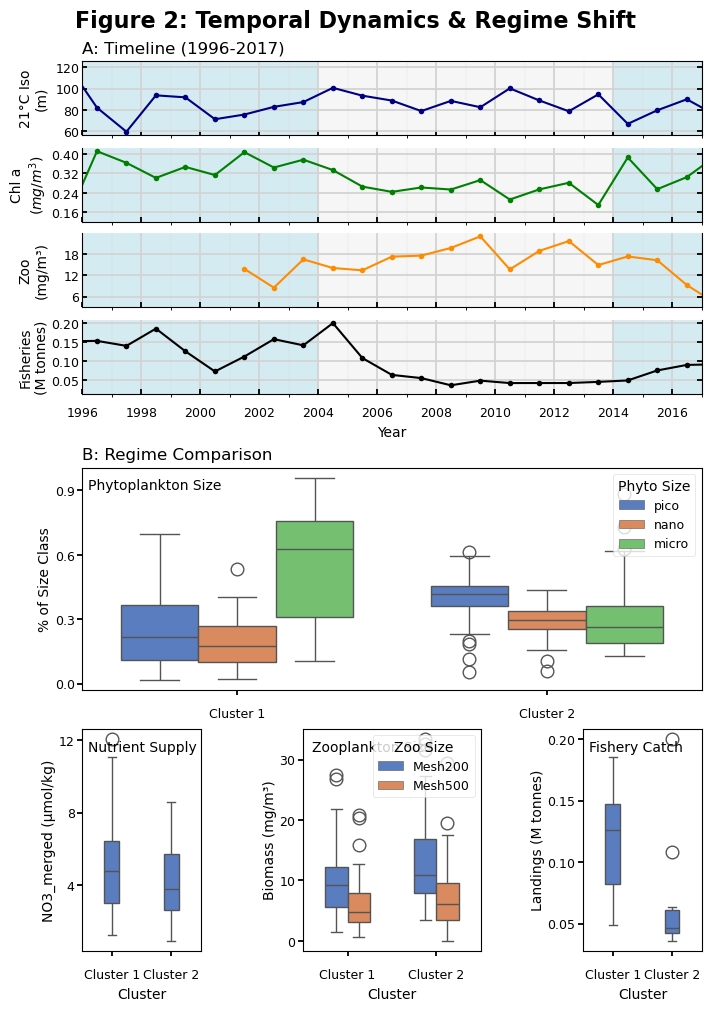

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (MODIFIED: New Grid for Alignment) ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: Define a 6-row, 3-col grid to force alignment.
# Rows 0-3 for timelines (40% total height)
# Rows 4-5 for boxplots (60% total height)
# Cols 0-2 for boxplot layout (width_ratios)
gs_main = fig.add_gridspec(6, 3, 
                           width_ratios=[2, 3, 2], 
                           height_ratios=[1, 1, 1, 1, 3, 3],
                           hspace=0) # hspace=0 for top 4 panels

# Top Panel: Timelines (Spanning all 3 columns)
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# Bottom Panel: Boxplots (in their defined grid cells)
axF = fig.add_subplot(gs_main[4, :]) # Phyto (spans row 4)
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

axE = fig.add_subplot(gs_main[5, 0]) # Nutrient (row 5, col 0)
axG = fig.add_subplot(gs_main[5, 1], sharex=axE) # Zoo (row 5, col 1)
axH = fig.add_subplot(gs_main[5, 2], sharex=axE) # Fisheries (row 5, col 2)


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data (MODIFIED: labelpad=2 for tighter y-labels)
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    # MODIFIED: pad=2 for tighter y-tick numbers
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes) # This will still work

# Remove top spines to close vertical gap
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Target individual box width
box_width = 0.25

# Top row: Phyto
# MODIFIED: width = 3 * box_width = 0.75
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.set_ylabel("% of Size Class", labelpad=2)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") 
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)
axF.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
axF.tick_params(axis='y', pad=2) # Tighter ticks

# Bottom row: Nutrients
# MODIFIED: width = 1 * box_width = 0.25
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)
axE.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
axE.tick_params(axis='y', pad=2) # Tighter ticks

# Bottom row: Zooplankton
# MODIFIED: width = 2 * box_width = 0.5
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.set_ylabel("Biomass (mg/m³)", labelpad=2)
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)
axG.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
axG.tick_params(axis='y', pad=2) # Tighter ticks

# Bottom row: Fisheries
# MODIFIED: width = 1 * box_width = 0.25
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)
axH.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
axH.tick_params(axis='y', pad=2) # Tighter ticks

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
# --- 7. Show Plot ---
plt.show()

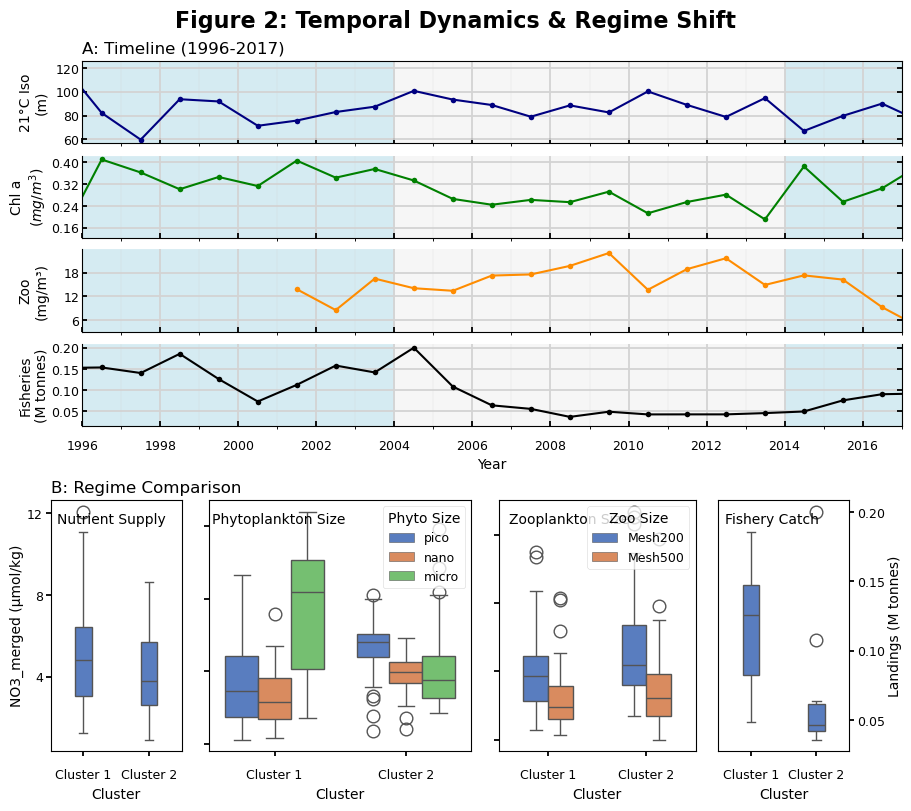

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (MODIFIED: New Layout) ---
# MODIFIED: New figsize
fig = plt.figure(figsize=(9, 8), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: 5 rows total. 4 for timelines, 1 for boxplots
gs_main = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 1, 3])

# --- Top Panel: Timelines ---
# Use subgridspec to group the top 4 rows
gs_top = gs_main[0:4].subgridspec(4, 1, hspace=0) 
axA = fig.add_subplot(gs_top[0])
axB = fig.add_subplot(gs_top[1], sharex=axA)
axC = fig.add_subplot(gs_top[2], sharex=axA)
axD = fig.add_subplot(gs_top[3], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots ---
# Use subgridspec for the 5th row
gs_bottom = gs_main[4].subgridspec(1, 4, 
                                 wspace=0.1, 
                                 width_ratios=[2, 4, 3, 2])
axE = fig.add_subplot(gs_bottom[0]) # Nutrient
axF = fig.add_subplot(gs_bottom[1], sharex=axE) # Phyto
axG = fig.add_subplot(gs_bottom[2], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom[3], sharex=axE) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Target individual box width
box_width = 0.25

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)
axF.set_ylabel("") # Hide y-label

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)
axG.set_ylabel("") # Hide y-label

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)
axH.yaxis.tick_right() # Move fisheries y-axis to the right
axH.yaxis.set_label_position("right")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.set_xlabel("Cluster")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)

# Hide inner y-tick labels
plt.setp(axF.get_yticklabels(), visible=False)
plt.setp(axG.get_yticklabels(), visible=False)
    
# --- 7. Show Plot ---
plt.show()

/var/folders/g_/s6xd0c9109v04q1j6n3spfh00000gn/T/ipykernel_48415/1135627888.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Cluster 1", "Cluster 2"])
/var/folders/g_/s6xd0c9109v04q1j6n3spfh00000gn/T/ipykernel_48415/1135627888.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Cluster 1", "Cluster 2"])
/var/folders/g_/s6xd0c9109v04q1j6n3spfh00000gn/T/ipykernel_48415/1135627888.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Cluster 1", "Cluster 2"])
/var/folders/g_/s6xd0c9109v04q1j6n3spfh00000gn/T/ipykernel_48415/1135627888.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

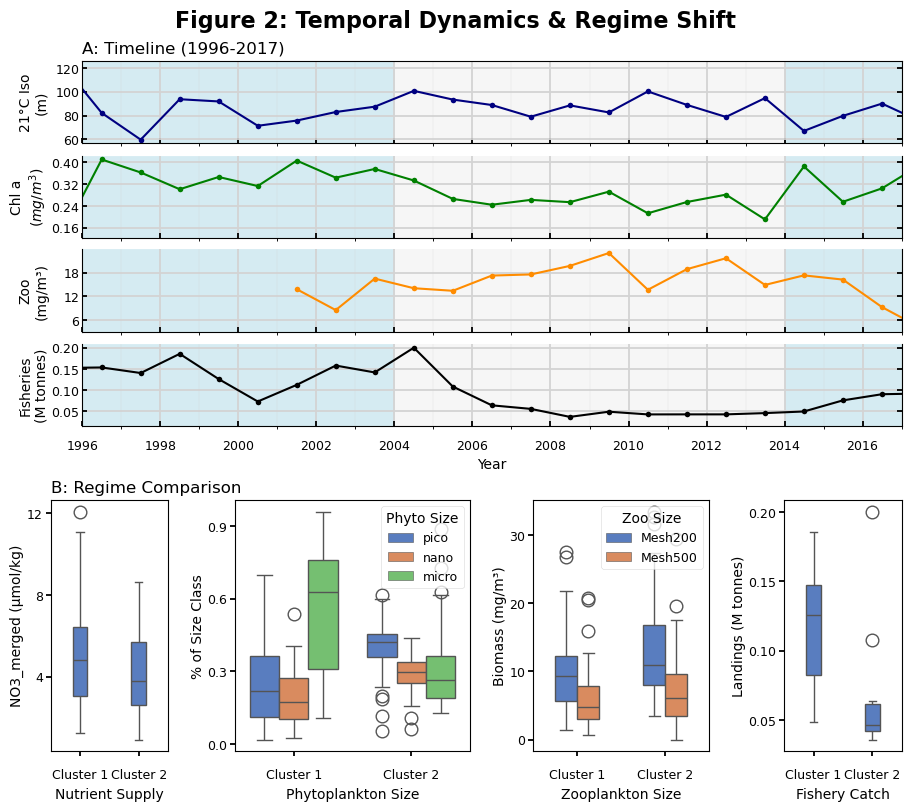

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(9, 8), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 1, 3])

# --- Top Panel: Timelines ---
gs_top = gs_main[0:4].subgridspec(4, 1, hspace=0) 
axA = fig.add_subplot(gs_top[0])
axB = fig.add_subplot(gs_top[1], sharex=axA)
axC = fig.add_subplot(gs_top[2], sharex=axA)
axD = fig.add_subplot(gs_top[3], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots ---
gs_bottom = gs_main[4].subgridspec(1, 4, 
                                 wspace=0.1, 
                                 width_ratios=[2, 4, 3, 2])
# MODIFIED: Removed sharex
axE = fig.add_subplot(gs_bottom[0]) # Nutrient
axF = fig.add_subplot(gs_bottom[1]) # Phyto
axG = fig.add_subplot(gs_bottom[2]) # Zoo
axH = fig.add_subplot(gs_bottom[3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Target individual box width
box_width = 0.25

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") # MODIFIED: New x-label

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) # MODIFIED: Show y-label
axF.set_xlabel("Phytoplankton Size") # MODIFIED: New x-label

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) # MODIFIED: Show y-label
axG.set_xlabel("Zooplankton Size") # MODIFIED: New x-label

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") # MODIFIED: New x-label
# MODIFIED: Ensure y-axis is on the left
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    # Set x-tick labels ("Cluster 1", "Cluster 2")
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

# MODIFIED: Remove lines that hid y-tick labels
# plt.setp(axF.get_yticklabels(), visible=False)
# plt.setp(axG.get_yticklabels(), visible=False)
    
# --- 7. Show Plot ---
plt.show()

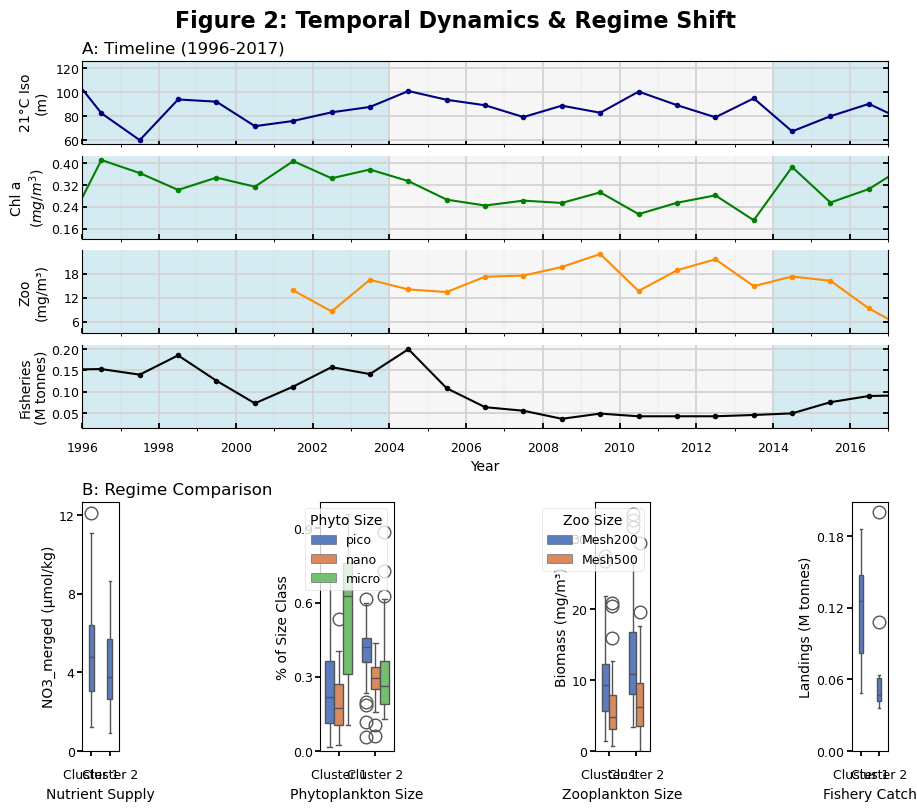

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (MODIFIED: New Grid for Alignment) ---
fig = plt.figure(figsize=(9, 8), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: Define a single 5x4 grid to force alignment
gs_main = fig.add_gridspec(5, 4, 
                           height_ratios=[1, 1, 1, 1, 3], 
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.1, hspace=0)

# --- Top Panel: Timelines (spanning all 4 columns) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (in their grid cells) ---
axE = fig.add_subplot(gs_main[4, 0]) # Nutrient
axF = fig.add_subplot(gs_main[4, 1]) # Phyto
axG = fig.add_subplot(gs_main[4, 2]) # Zoo
axH = fig.add_subplot(gs_main[4, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Target individual box width
box_width = 0.25

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    
    # MODIFIED: Set ylim to start at 0
    ax.set_ylim(bottom=0)
    
    # MODIFIED: Fix for UserWarning
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

    
# --- 7. Show Plot ---
plt.show()

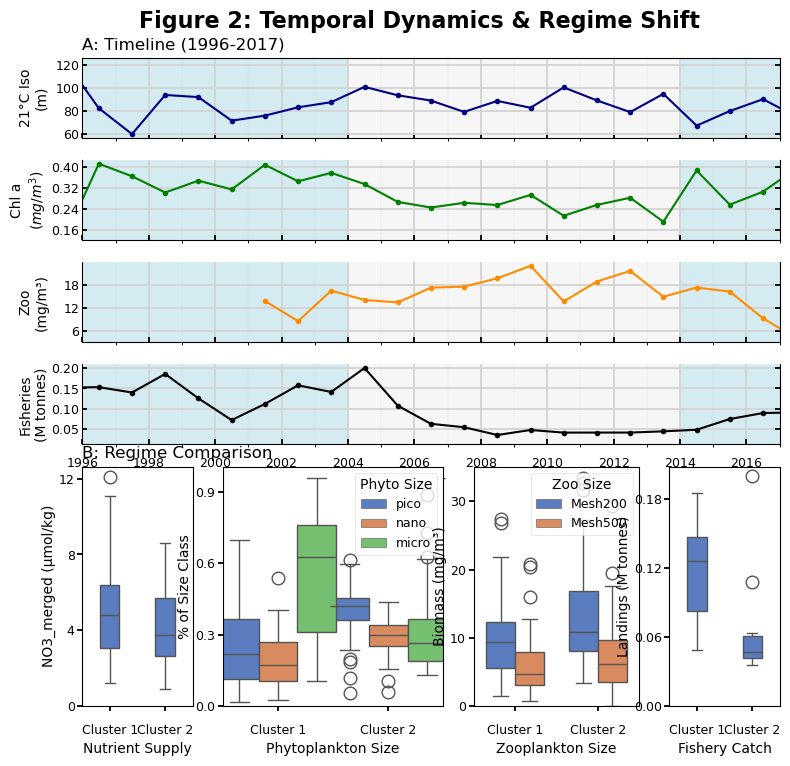

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
# MODIFIED: Removed constrained_layout=True
fig = plt.figure(figsize=(9, 8)) 
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# The GridSpec will now control the layout perfectly
gs_main = fig.add_gridspec(5, 4, 
                           height_ratios=[1, 1, 1, 1, 3], 
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.2, hspace=0.2) # wspace=0.1 gives small gaps

# --- Top Panel: Timelines (spanning all 4 columns) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (in their grid cells) ---
axE = fig.add_subplot(gs_main[4, 0]) # Nutrient
axF = fig.add_subplot(gs_main[4, 1]) # Phyto
axG = fig.add_subplot(gs_main[4, 2]) # Zoo
axH = fig.add_subplot(gs_main[4, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# MODIFIED: Increased base width for all boxes
box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

# MODIFIED: Manually adjust layout to make room for suptitle
fig.subplots_adjust(top=0.92) 
    
# --- 7. Show Plot ---
plt.show()

/Users/aoop/micromamba/envs/xso2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


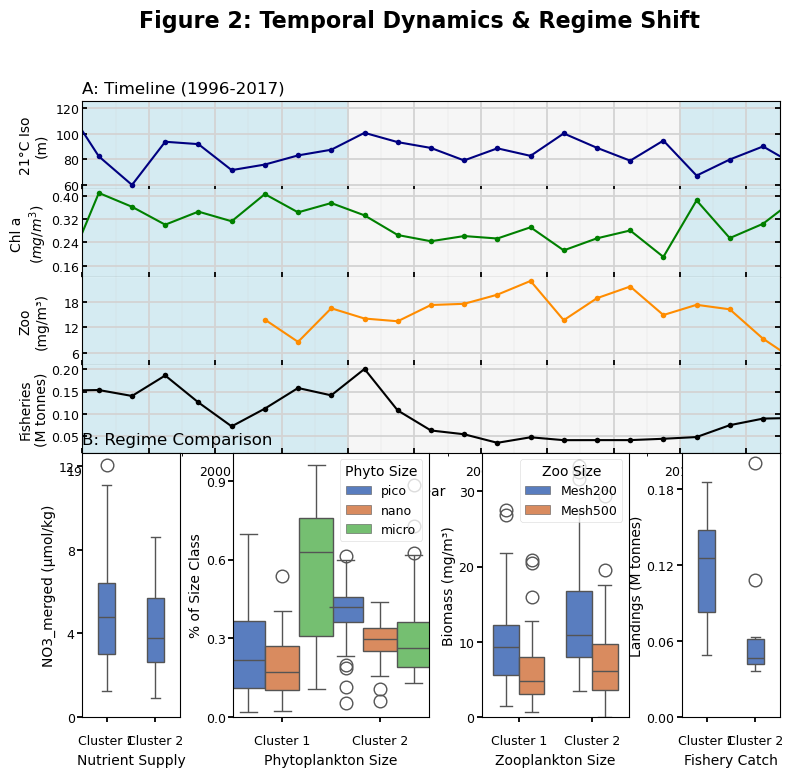

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(9, 8), constrained_layout=True) 
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(5, 4, 
                           height_ratios=[1, 1, 1, 1, 3], 
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.4, hspace=0)

# --- Top Panel: Timelines (spanning all 4 columns) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (in their grid cells) ---
axE = fig.add_subplot(gs_main[4, 0]) # Nutrient
axF = fig.add_subplot(gs_main[4, 1]) # Phyto
axG = fig.add_subplot(gs_main[4, 2]) # Zoo
axH = fig.add_subplot(gs_main[4, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
# --- THIS LINE IS NOW FIXED ---
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Keep boxes legible
box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

    
# --- 7. Show Plot ---
plt.show()

/Users/aoop/micromamba/envs/xso2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


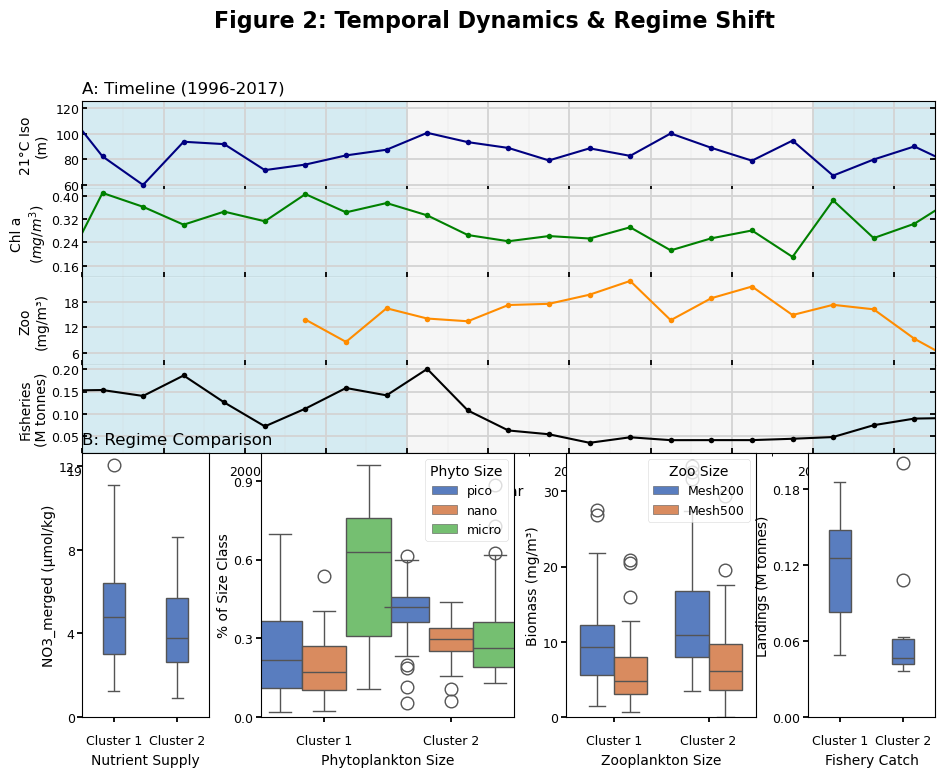

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
# MODIFIED: Increased figsize to (11, 8) to fix constrained_layout warning
fig = plt.figure(figsize=(11, 8), constrained_layout=True) 
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: Reduced wspace to 0.3
gs_main = fig.add_gridspec(5, 4, 
                           height_ratios=[1, 1, 1, 1, 3], 
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.3, hspace=0)

# --- Top Panel: Timelines (spanning all 4 columns) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (in their grid cells) ---
axE = fig.add_subplot(gs_main[4, 0]) # Nutrient
axF = fig.add_subplot(gs_main[4, 1]) # Phyto
axG = fig.add_subplot(gs_main[4, 2]) # Zoo
axH = fig.add_subplot(gs_main[4, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
# --- THIS LINE IS NOW FIXED ---
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Keep boxes legible
box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

    
# --- 7. Show Plot ---
plt.show()

/Users/aoop/micromamba/envs/xso2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


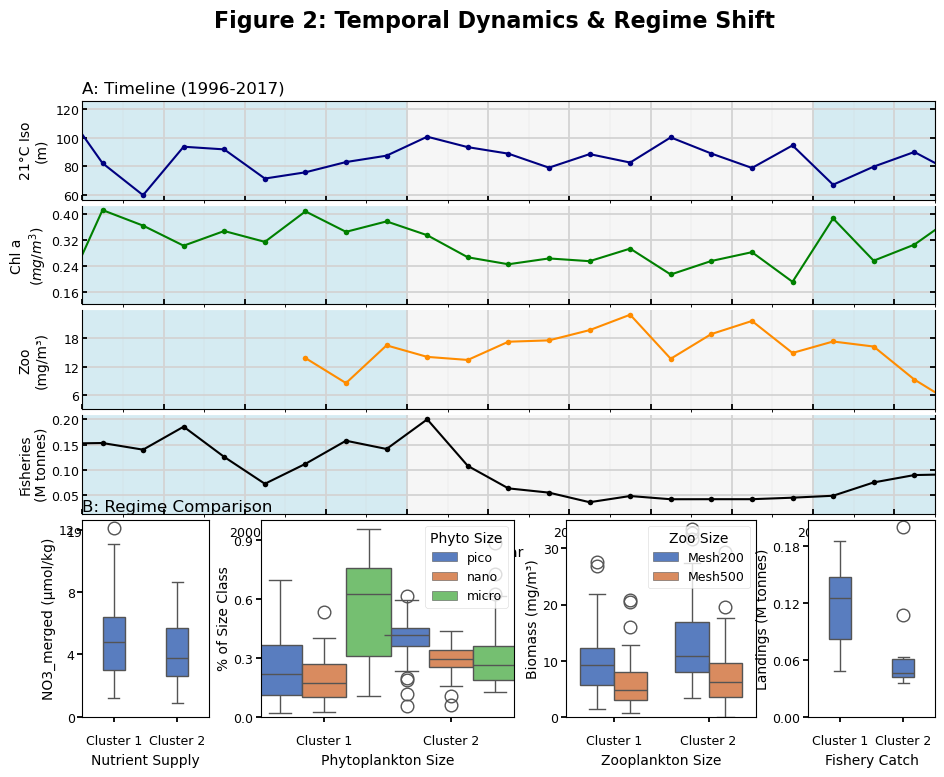

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
# Using (11, 8) as it fixed the previous constrained_layout warning
fig = plt.figure(figsize=(11, 8), constrained_layout=True) 
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: Adjusted height_ratios and hspace
gs_main = fig.add_gridspec(5, 4, 
                           height_ratios=[2, 2, 2, 2, 4], 
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.3, hspace=0.05) 

# --- Top Panel: Timelines (spanning all 4 columns) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (in their grid cells) ---
axE = fig.add_subplot(gs_main[4, 0]) # Nutrient
axF = fig.add_subplot(gs_main[4, 1]) # Phyto
axG = fig.add_subplot(gs_main[4, 2]) # Zoo
axH = fig.add_subplot(gs_main[4, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines (this still works to create the stacked effect)
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Keep boxes legible
box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

    
# --- 7. Show Plot ---
plt.show()

/Users/aoop/micromamba/envs/xso2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


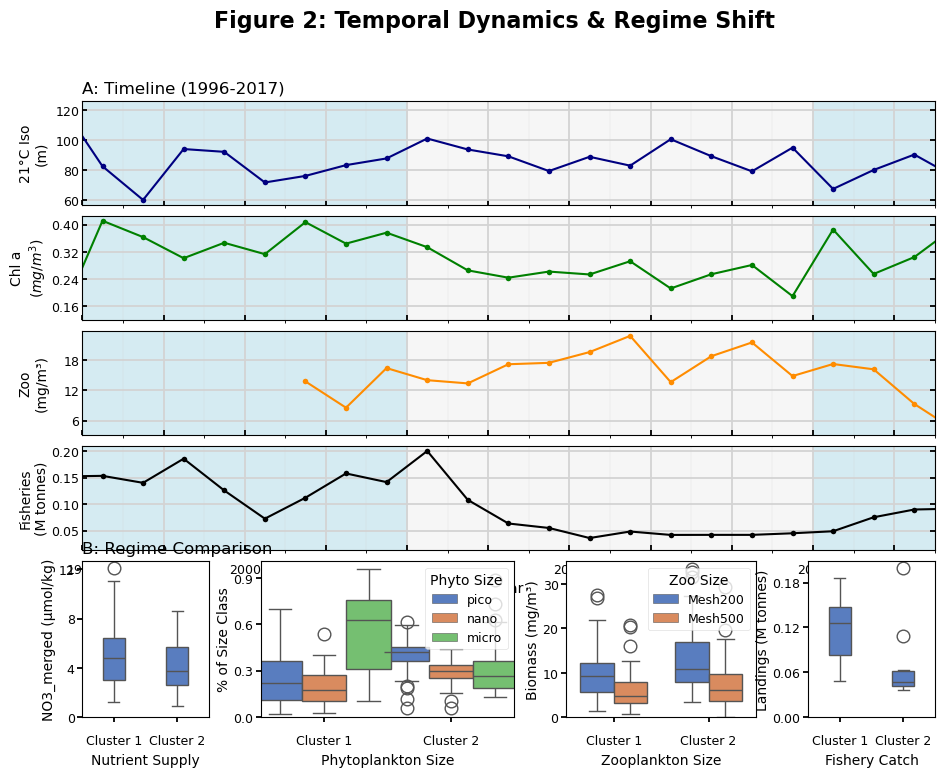

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
# Use (11, 8) as it fixed the previous constrained_layout warning
fig = plt.figure(figsize=(11, 8), constrained_layout=True) 
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: Back to a single GridSpec for alignment
# hspace=0.1 will apply to all rows, creating the gap
# height_ratios gives timelines more space
gs_main = fig.add_gridspec(5, 4, 
                           height_ratios=[2, 2, 2, 2, 3], 
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.3, hspace=0.1) 

# --- Top Panel: Timelines (spanning all 4 columns) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (in their grid cells) ---
# These will now align with axA because they share a GridSpec
axE = fig.add_subplot(gs_main[4, 0]) # Nutrient
axF = fig.add_subplot(gs_main[4, 1]) # Phyto
axG = fig.add_subplot(gs_main[4, 2]) # Zoo
axH = fig.add_subplot(gs_main[4, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# MODIFIED: We can no longer remove top spines as hspace > 0
# axB.spines['top'].set_visible(False)
# axC.spines['top'].set_visible(False)
# axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Keep boxes legible
box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 3)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 2)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

    
# --- 7. Show Plot ---
plt.show()